In [1]:
import itertools
import math

import fitstream as fts
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from scipy import interpolate as interp
import seaborn as sns
import torch
from torch import nn

mpl.rcParams['figure.dpi'] = 140

# Function generation and plotting

In [26]:
def random_func(m: int, sigma: float=1., lower=-4, upper=4, rng: np.random.Generator = None):
    if rng is None:
        rng = np.random.default_rng(42)
    
    ts = np.linspace(lower, upper, m)
    ys = rng.normal(0.0, sigma, size=m)
    return interp.CubicSpline(ts, ys, bc_type="natural", extrapolate=True)

In [30]:
def random_inc_func(m: int, sigma: float=1., lower=-4, upper=4, rng: np.random.Generator = None):
    if rng is None:
        rng = np.random.default_rng(42)
    
    ts = np.r_[lower, lower, lower, np.linspace(lower, upper, m), upper, upper, upper]
    cs = np.cumsum(np.exp(rng.normal(0.0, sigma, size=m + 3)))
    return interp.BSpline(ts, cs, k=3, extrapolate=True)

In [11]:
def func_gallery(random_func_fn, rng, ms=[3, 5, 10, 20]):
    n_cols = int(math.ceil(math.sqrt(len(ms))))
    n_rows = int(math.ceil(len(ms) / n_cols))

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), layout='constrained')
    xs = np.linspace(-4, 4, 1000)

    for m, ax in zip(ms, axs.ravel()):
        func = random_func_fn(m)
        ax.plot(xs, func(xs))
        ax.set_title(f'$f_{{{m}}}(x)$')

# Model training

In [12]:
def train_stream(func, model, lower=-4, upper=4, noise_std=0., batch_size=32, lr=1e-3, rng=None, test_res=10000):
    if rng is None:
        rng = np.random.default_rng(42)

    # create a test set
    xs_test = torch.linspace(lower, upper, test_res).reshape(-1, 1)
    ys_test = torch.as_tensor(func(xs_test.numpy())).squeeze(-1)

    # setup variables for mini-batch loop
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # run training loop
    for step in itertools.count(start=1):
        xs_batch = rng.uniform(lower, upper, size=(batch_size, 1))
        ys_batch = func(xs_batch).squeeze(-1)
        if noise_std > 0:
            ys_batch = ys_batch + rng.random.standard_normal(size=(batch_size,))

        xs_batch = torch.as_tensor(xs_batch, dtype=torch.float32)
        ys_batch = torch.as_tensor(ys_batch, dtype=torch.float32)

        loss = criterion(model(xs_batch), ys_batch)
        
        optim.zero_grad()
        loss.backward()
        optim.step()

        with torch.no_grad():
            test_mse = criterion(model(xs_test), ys_test)

        yield {
            'step': step,
            'test_rmse': math.sqrt(test_mse.item()),
        }

In [13]:
class TrilEmbed(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

        # Get the coordinates of the lower triangle
        i, j = torch.tril_indices(dim, dim)

        # Build a lookup grid: which index of the input belongs at (row, col)?
        grid = torch.zeros(dim, dim, dtype=torch.long)
        grid[i, j] = torch.arange(len(i))

        # Symmetrize the map: copy lower indices to upper
        grid = torch.maximum(grid, grid.T)

        # Store the flattened map as a buffer
        self.map = nn.Buffer(grid.flatten())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Expands x of shape (..., K) to (..., d, d),  where K = d * (d + 1) // 2
        """
        return x[..., self.map].view(*x.shape[:-1], self.dim, self.dim)

In [14]:
class KthEigval(nn.Module):
    def __init__(self, num_features, dim, k=None):
        super().__init__()
        self.lin = nn.Linear(num_features, dim * (dim + 1) // 2)
        self.tril_emb = TrilEmbed(dim)
        self.k = k or dim // 2

    def forward(self, x):
        mat_flat = self.lin(x)
        mat = self.tril_emb(mat_flat)
        eigvals = torch.linalg.eigvalsh(mat)
        return eigvals[..., self.k]

In [15]:
class KthEigval1DMonotone(nn.Module):
    def __init__(self, dim, k=None, alpha=0.1):
        super().__init__()
        self.bias_mat = nn.Parameter(torch.randn(dim * (dim + 1) // 2) / math.sqrt(dim))
        self.feat_vec = nn.Parameter(torch.randn(dim) / math.sqrt(dim))
        self.tril_emb = TrilEmbed(dim)
        self.k = k or dim // 2

    def forward(self, x):
        feat_diag = nn.functional.softplus(self.feat_vec)
        mat = self.tril_emb(self.bias_mat)[None] + torch.diag_embed(x[:, None] * feat_diag)
        eigvals = torch.linalg.eigvalsh(mat)
        return eigvals[..., self.k]

In [16]:
def compute_scaling_law(model_fn, random_func_fn, n_batches=200):
    train_logs = []
    for lr in np.geomspace(1e-4, 1e-1, 10):
        events = fts.pipe(
            train_stream(random_func_fn(), model_fn(), lr=lr),
            fts.take(n_batches)
        )
        train_log = fts.collect_pd(events)
        train_logs.append(train_log)
    
    return pd.concat(train_logs, axis=0) \
        .groupby("step")["test_rmse"] \
        .min() \
        .sort_index() \
        .cummin() \
        .to_frame()

# General functions

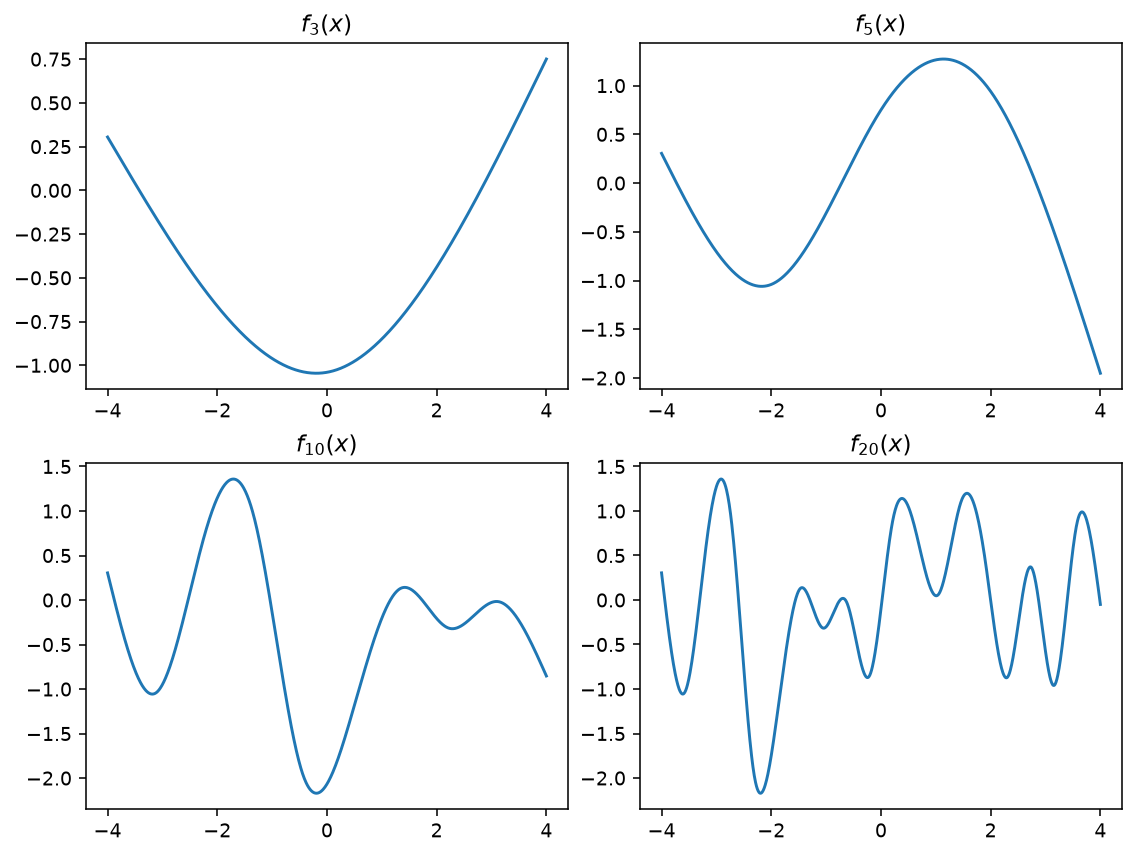

In [28]:
func_gallery(random_func, np.random.default_rng(42))

In [9]:
dims = [3, 5, 10]
complexities = [3, 5, 10, 20]
scaling_laws = []
for complexity in complexities:
    for dim in dims:
        scaling_law = compute_scaling_law(KthEigval(1, dim), complexity)
        scaling_law['dim'] = dim
        scaling_law['complexity'] = complexity
        scaling_laws.append(scaling_law.reset_index())

In [10]:
scaling_laws_df = pd.concat(scaling_laws, axis=0)

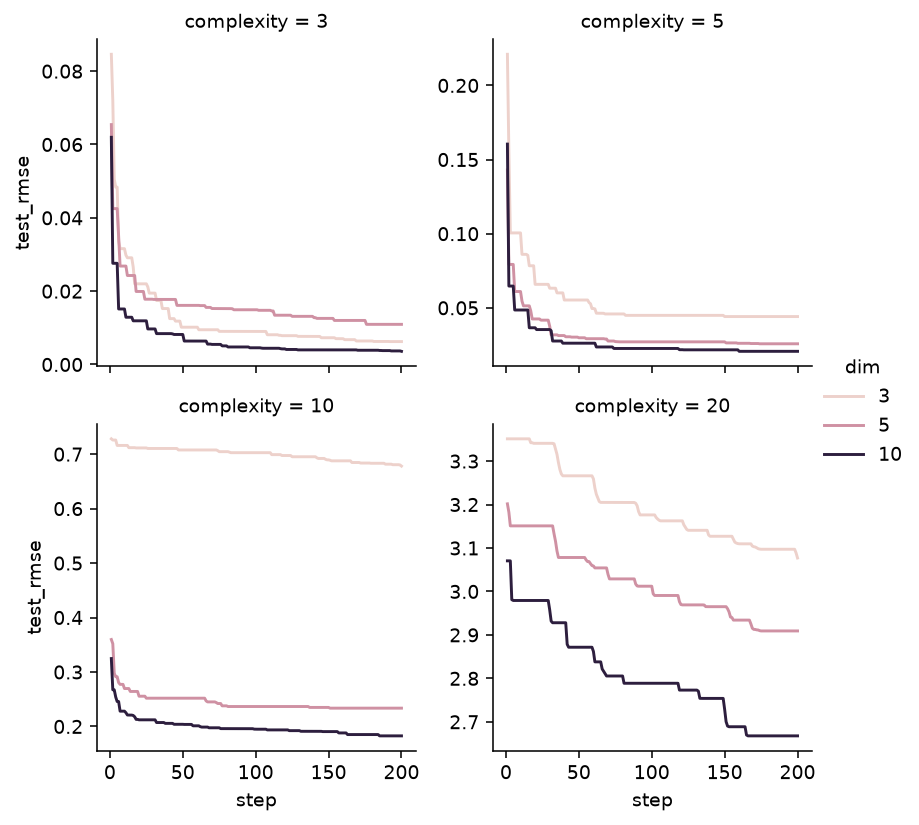

In [11]:
sns.relplot(scaling_laws_df, kind='line', x='step', y='test_rmse', col='complexity', hue='dim', 
            col_wrap=2, height=3, facet_kws={'sharey': False, 'sharex': True})

# Monotone functions

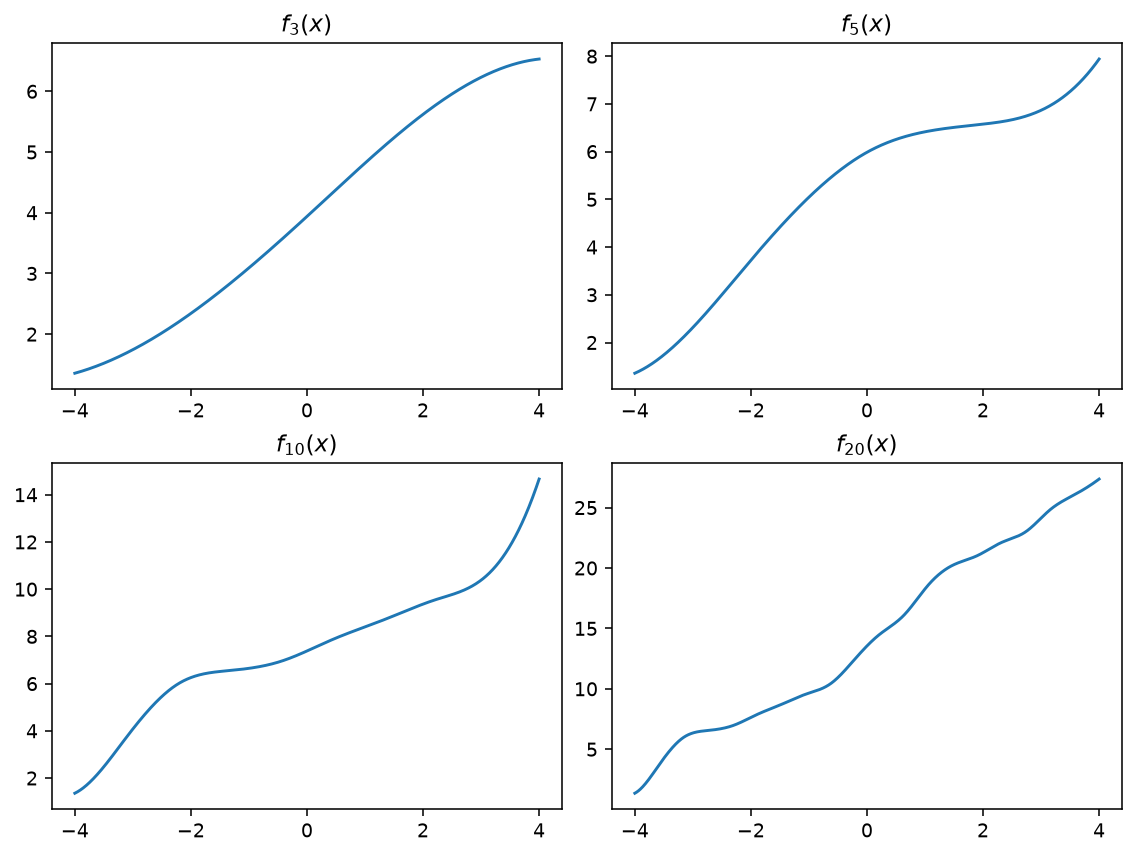

In [31]:
func_gallery(random_inc_func, np.random.default_rng(42))

In [ ]:
dims = [3, 5, 10]
complexities = [3, 5, 10, 20]
scaling_laws = []
for complexity in complexities:
    for dim in dims:
        scaling_law = compute_scaling_law(KthEigval(1, dim), complexity)
        scaling_law['dim'] = dim
        scaling_law['complexity'] = complexity
        scaling_laws.append(scaling_law.reset_index())

        scaling_law = compute_scaling_law(KthEigval(1, dim), complexity)
        scaling_law['dim'] = dim
        scaling_law['complexity'] = complexity
        scaling_laws.append(scaling_law.reset_index())